29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape: (60000, 784)


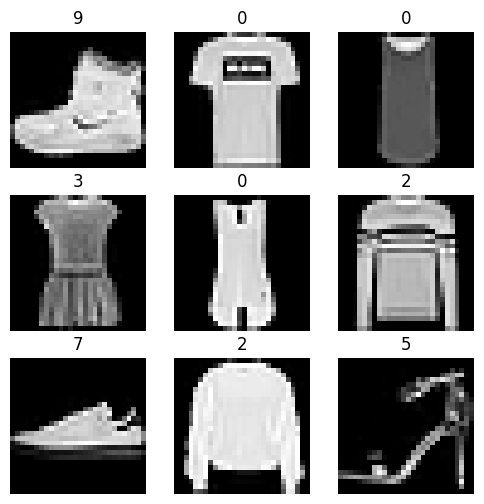

Explained Variance Ratio: [0.29039228 0.1775531 ]


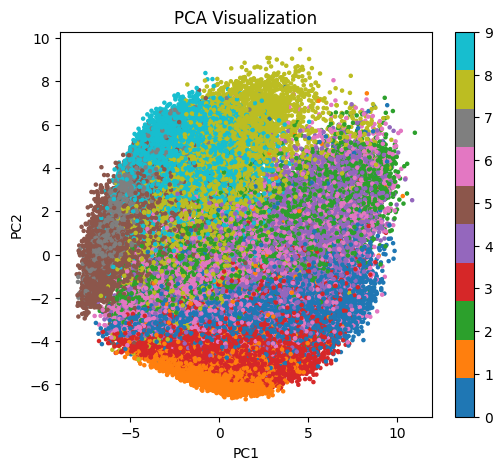

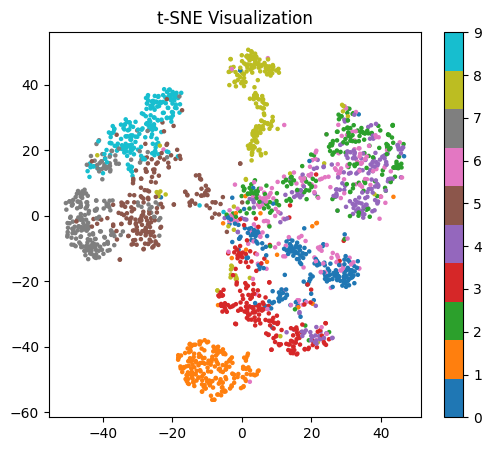

PCA Time: 0.12947845458984375
t-SNE Time: 10.48255443572998


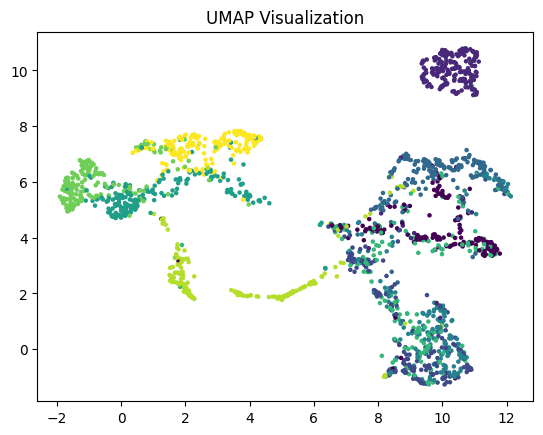

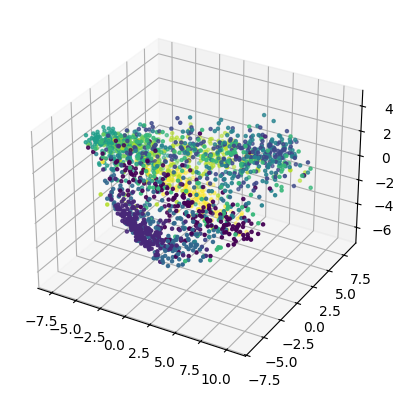

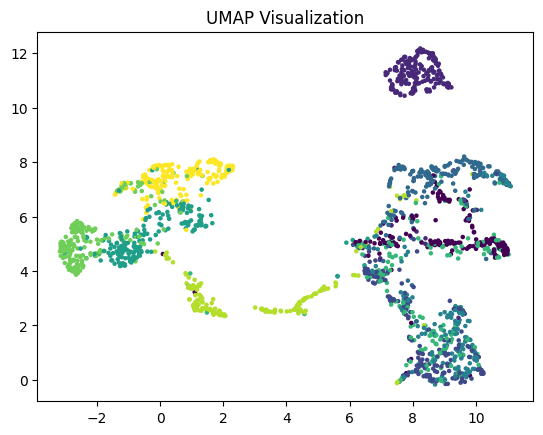

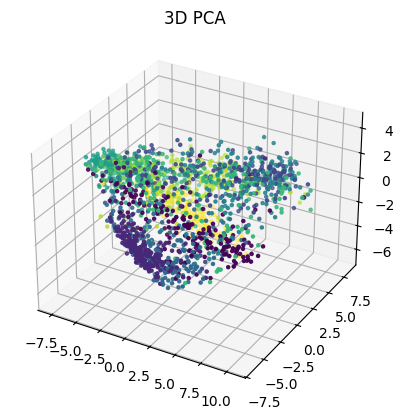

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# Load dataset
(X_train, y_train), (_, _) = fashion_mnist.load_data()

# Normalize
X = X_train / 255.0

# Flatten (28x28 → 784)
X_flat = X.reshape(X.shape[0], -1)

print("Shape:", X_flat.shape)

# Show sample images
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_flat)

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# Plot PCA
plt.figure(figsize=(6,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, cmap='tab10', s=5)
plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter)
plt.show()

from sklearn.manifold import TSNE

# Reduce dataset size (t-SNE is slow)
X_sample = X_flat[:2000]
y_sample = y_train[:2000]

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_sample)

# Plot t-SNE
plt.figure(figsize=(6,5))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_sample, cmap='tab10', s=5)
plt.title("t-SNE Visualization")
plt.colorbar(scatter)
plt.show()

import time

# PCA Time
start = time.time()
PCA(n_components=2).fit_transform(X_flat[:2000])
print("PCA Time:", time.time() - start)

# t-SNE Time
start = time.time()
TSNE(n_components=2).fit_transform(X_flat[:2000])
print("t-SNE Time:", time.time() - start)

import umap

reducer = umap.UMAP()
X_umap = reducer.fit_transform(X_flat[:2000])

plt.scatter(X_umap[:,0], X_umap[:,1], c=y_train[:2000], s=5)
plt.title("UMAP Visualization")
plt.show()

from mpl_toolkits.mplot3d import Axes3D

pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_flat[:2000])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=y_train[:2000], s=5)
plt.show()

import umap

reducer = umap.UMAP()
X_umap = reducer.fit_transform(X_flat[:2000])

plt.scatter(X_umap[:,0], X_umap[:,1], c=y_train[:2000], s=5)
plt.title("UMAP Visualization")
plt.show()

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_flat[:2000])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=y_train[:2000], s=5)
plt.title("3D PCA")
plt.show()